# 07 · Full pipeline over a real AOI

**Objective:** Put the pipeline together over the whole Alicante marina
AOI: RPN removal, full hypothesis library per point, and maps of the
results (default velocity, post-determined velocity, thermal expansion,
fraction sustaining H0) in the style of the paper's Fig. 7.

Unwrapping correction (notebook 06) is not re-run here: at ~4.3s/point it
is not practical over 38598 points with the current implementation, and
notebook 06 already found it affects a small fraction of points (2/30 in
a sample).

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from insar_mht import library, hypotheses, testing, dia, rpn, unwrap, reliability
from insar_mht.io import egms, temperature

In [2]:
ds = egms.load_cached(
    "../data/processed/alicante_marina_metadata.parquet",
    "../data/processed/alicante_marina_displacements.parquet",
)
temp = temperature.load_daily_temperature("../data/processed/alicante_daily_temperature.csv")
dates = ds.dates
t = (dates - dates[0]).days.to_numpy() / 365.25
delta_temp = temperature.delta_temp_for_dates(temp, dates)
m = len(t)

wide = ds.displacements.pivot(index="pid", columns="date", values="displacement_mm")
wide = wide[dates]
Y_all = wide.to_numpy()
pids_all = wide.index.to_numpy()
meta = ds.metadata.set_index("pid").loc[pids_all]

Y_all, e_hat_rp = rpn.remove_rpn(Y_all, t)
print(f"{Y_all.shape[0]} points, {m} epochs, RPN removed (see notebook 06: effect is small for this AOI)")

38598 points, 210 epochs, RPN removed (see notebook 06: effect is small for this AOI)


In [3]:
A0 = library.design_matrix_h0(t)
sigma = 3.0
Qyy = (sigma ** 2) * np.eye(m)
Qyy_inv = np.linalg.inv(Qyy)
normal_matrix = A0.T @ Qyy_inv @ A0
n_inv = np.linalg.inv(normal_matrix)
q_ehat_ehat = np.linalg.inv(Qyy_inv) - A0 @ n_inv @ A0.T
P0 = n_inv @ A0.T @ Qyy_inv          # x_hat0 = P0 @ y
M0 = np.eye(m) - A0 @ P0             # e_hat0 = M0 @ y

alpha0 = 1 / (2 * m)
gamma0 = 0.5
q0 = m - A0.shape[1]
K = stats.chi2.ppf(1 - alpha0, q0)
lambda0 = testing.noncentrality_from_power(gamma0, alpha0, q=1)

library_hyps = hypotheses.table_i_hypotheses(t, delta_temp, beta_grid=[0.1, 0.25, 0.5, 1.0])
precomputed = [dia.precompute_hypothesis_class(h, Qyy_inv, q_ehat_ehat, lambda0, gamma0) for h in library_hyps]
L_stack = np.stack([p.L for p in precomputed])
critical_values = np.array([p.critical_value for p in precomputed])
print(f"{len(precomputed)} hypotheses precomputed")

1264 hypotheses precomputed


## Detection and identification for every point

Batched over the whole AOI, following notebook 05's pattern: `T0` and the
test ratios for all 1264 hypotheses computed for every point in one pass.

In [4]:
def batched_ratios_and_omt(Y, M, L_stack, critical_values, sigma):
    E = Y @ M.T
    T0_batch = (E ** 2).sum(axis=1) / sigma ** 2
    temp_ = L_stack @ E.T
    Tq = np.einsum("hip,pi->hp", temp_, E)
    return T0_batch, (Tq / critical_values[:, None]).T


n_points = len(Y_all)
all_T0 = np.empty(n_points)
all_best_ratio = np.empty(n_points)
all_best_hyp_idx = np.empty(n_points, dtype=int)

BATCH_SIZE = 300
t_start = time.perf_counter()
for start in range(0, n_points, BATCH_SIZE):
    batch = Y_all[start:start + BATCH_SIZE]
    T0_batch, ratios_batch = batched_ratios_and_omt(batch, M0, L_stack, critical_values, sigma)
    idx = ratios_batch.argmax(axis=1)
    all_T0[start:start + len(batch)] = T0_batch
    all_best_hyp_idx[start:start + len(batch)] = idx
    all_best_ratio[start:start + len(batch)] = ratios_batch[np.arange(len(batch)), idx]
print(f"{time.perf_counter()-t_start:.0f}s for {n_points} points")

sustains_h0 = all_T0 <= K
rejects_h0 = ~sustains_h0
found_better_model = rejects_h0 & (all_best_ratio > 1)
rejects_no_model = rejects_h0 & ~found_better_model

print(f"sustain H0:              {sustains_h0.sum():6d} ({100*sustains_h0.mean():.1f}%)")
print(f"reject H0, model found:  {found_better_model.sum():6d} ({100*found_better_model.mean():.1f}%)")
print(f"reject H0, no model wins:{rejects_no_model.sum():6d} ({100*rejects_no_model.mean():.1f}%)")

2109s for 38598 points
sustain H0:               22207 (57.5%)
reject H0, model found:   16304 (42.2%)
reject H0, no model wins:    87 (0.2%)


## Adaptation: estimate parameters for every point

Points that sustain H0, or reject it without a winning alternative, keep
the H0 fit (velocity only). Points with a winning hypothesis need a GLS
refit with the augmented design matrix `[A0, C_winner]`. Points sharing
the same winning hypothesis share the same augmented matrix, so group by
winning hypothesis index and refit each group in one batched solve
instead of one point at a time.

In [5]:
def eta_col_index(hypothesis_name):
    """Position of the thermal-expansion column (M2) inside each hypothesis's
    C matrix, per its construction in hypotheses.table_i_hypotheses. None if
    the hypothesis has no thermal term.
    """
    if hypothesis_name.startswith(("H1_", "H6_", "H7_")):
        return 0
    if hypothesis_name.startswith("H4_"):
        return 1
    return None


all_v_hat_h0 = (P0 @ Y_all.T).flatten()  # H0 velocity for every point
all_v_hat = all_v_hat_h0.copy()          # post-determined velocity, overwritten below where a model won
all_eta_hat = np.full(n_points, np.nan)
winning_name = np.full(n_points, "H0", dtype=object)

t_start = time.perf_counter()
for hyp_idx in np.unique(all_best_hyp_idx[found_better_model]):
    mask = found_better_model & (all_best_hyp_idx == hyp_idx)
    hyp = precomputed[hyp_idx].hypothesis
    A_aug = np.column_stack([A0, hyp.C])
    n_inv_aug = np.linalg.inv(A_aug.T @ Qyy_inv @ A_aug)
    P_aug = n_inv_aug @ A_aug.T @ Qyy_inv
    X_hat = P_aug @ Y_all[mask].T

    all_v_hat[mask] = X_hat[0]
    winning_name[mask] = hyp.name
    eta_idx = eta_col_index(hyp.name)
    if eta_idx is not None:
        all_eta_hat[mask] = X_hat[1 + eta_idx]

print(f"{time.perf_counter()-t_start:.1f}s to refit {len(np.unique(all_best_hyp_idx[found_better_model]))} "
      f"hypothesis groups covering {found_better_model.sum()} points")

0.9s to refit 1217 hypothesis groups covering 16304 points


## Maps

Same layout as the paper's Fig. 7: default H0 velocity, points sustaining
H0, the post-determined velocity, and the thermal expansion parameter for
points whose winning model includes it.

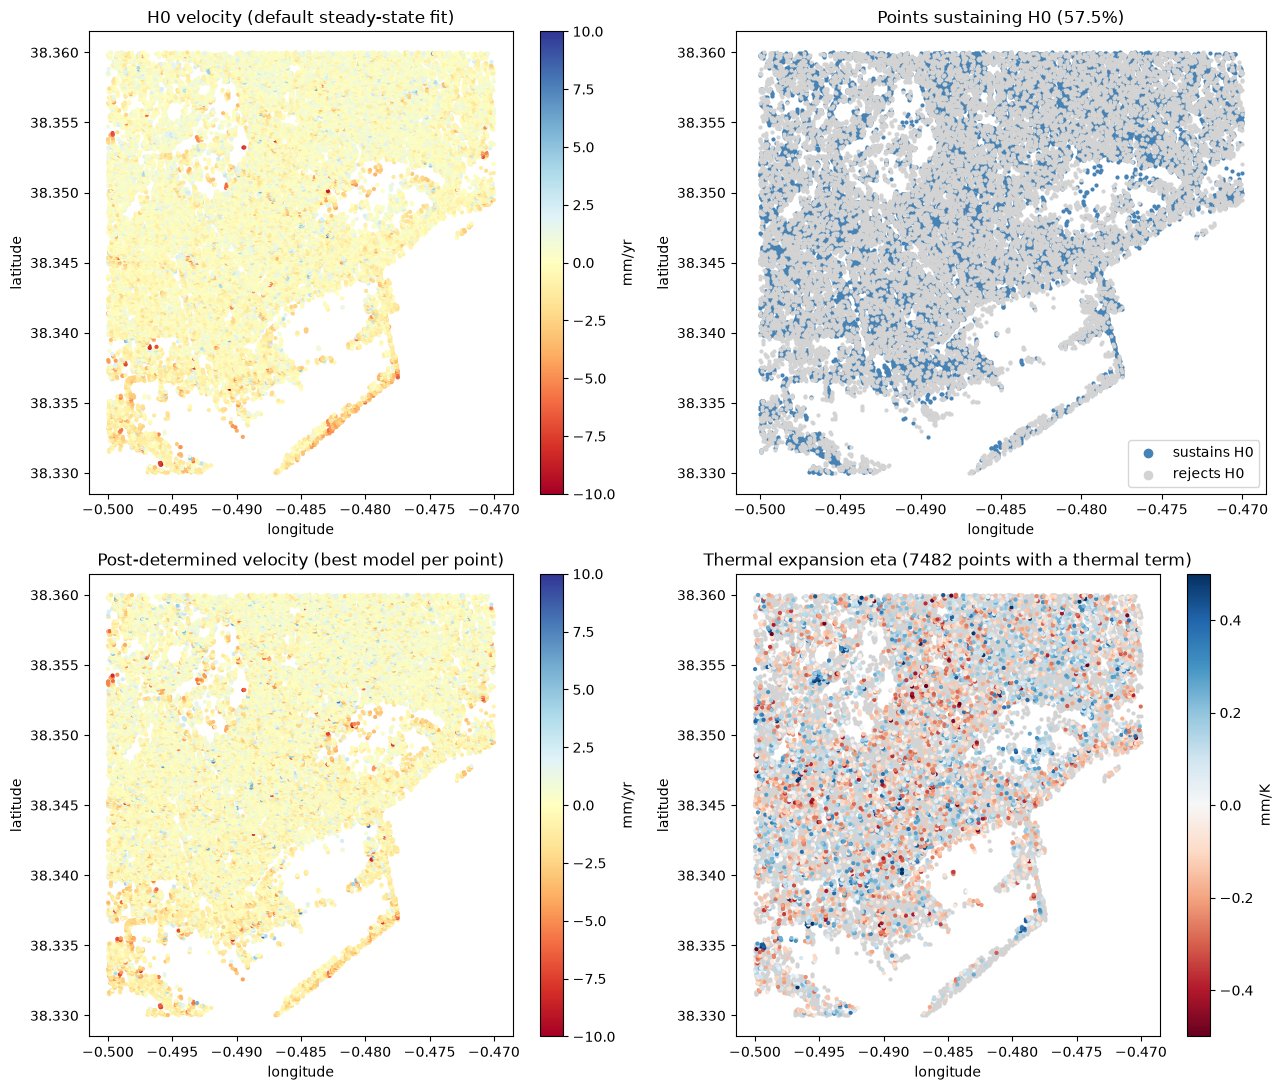

In [6]:
lon = meta["longitude"].to_numpy()
lat = meta["latitude"].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

sc0 = axes[0, 0].scatter(lon, lat, c=all_v_hat_h0, cmap="RdYlBu", vmin=-10, vmax=10, s=4)
axes[0, 0].set_title("H0 velocity (default steady-state fit)")
plt.colorbar(sc0, ax=axes[0, 0], label="mm/yr")

axes[0, 1].scatter(lon[sustains_h0], lat[sustains_h0], c="steelblue", s=4, label="sustains H0")
axes[0, 1].scatter(lon[~sustains_h0], lat[~sustains_h0], c="lightgray", s=4, label="rejects H0")
axes[0, 1].set_title(f"Points sustaining H0 ({100*sustains_h0.mean():.1f}%)")
axes[0, 1].legend(markerscale=3)

sc2 = axes[1, 0].scatter(lon, lat, c=all_v_hat, cmap="RdYlBu", vmin=-10, vmax=10, s=4)
axes[1, 0].set_title("Post-determined velocity (best model per point)")
plt.colorbar(sc2, ax=axes[1, 0], label="mm/yr")

has_eta = ~np.isnan(all_eta_hat)
axes[1, 1].scatter(lon[~has_eta], lat[~has_eta], c="lightgray", s=4)
sc3 = axes[1, 1].scatter(lon[has_eta], lat[has_eta], c=all_eta_hat[has_eta], cmap="RdBu", vmin=-0.5, vmax=0.5, s=4)
axes[1, 1].set_title(f"Thermal expansion eta ({has_eta.sum()} points with a thermal term)")
plt.colorbar(sc3, ax=axes[1, 1], label="mm/K")

for ax in axes.flat:
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.tight_layout()

mean |v_diff| where a model won: 1.29 mm/yr
max |v_diff|: 7.77 mm/yr


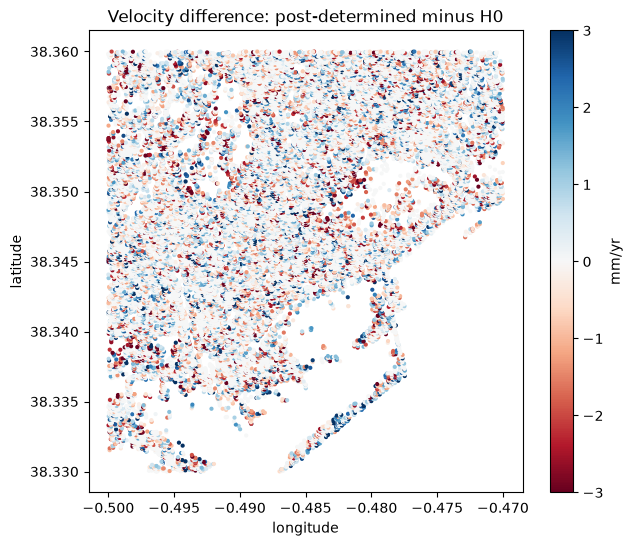

In [7]:
v_diff = all_v_hat - all_v_hat_h0

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(lon, lat, c=v_diff, cmap="RdBu", vmin=-3, vmax=3, s=4)
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("Velocity difference: post-determined minus H0")
plt.colorbar(sc, label="mm/yr")

print(f"mean |v_diff| where a model won: {np.abs(v_diff[found_better_model]).mean():.2f} mm/yr")
print(f"max |v_diff|: {np.abs(v_diff).max():.2f} mm/yr")

## Summary

57.5% of points sustain H0 in this AOI, against 84% in the paper's
Rotterdam case. Notebook 05's
mid-series hump around epoch 120-140 (Aug 2021 to Feb 2022) accounts for
part of it, and notebook 06 ruled out reference point noise as the cause.
What is actually driving that shared structure (a real regional event, an
atmospheric artifact common to the stack, or something else) is not
resolved here.

Where a model did win, the effect on velocity is moderate: mean
|difference| of 1.29 mm/yr, up to 7.77 mm/yr at individual points. Sticking
to H0 everywhere would misstate the deformation rate for roughly 42% of
points in this AOI by a non-trivial amount.